# Análise de Carga e Geração — Copa do Mundo
## Brasil | 2014 × 2026

Este estudo analisa o comportamento da **carga elétrica** e da **composição da geração** nos horários dos jogos do Brasil nas Copas do Mundo de 2014 e 2026, utilizando a base histórica do ONS.

A análise é feita para o **Sistema Interligado Nacional (SIN)** e compara os resultados com uma referência de carga construída a partir dos mesmos horários em uma janela de ±7 dias.

**Nota sobre esta versão:** os horários dos jogos de 2026 foram conferidos e corrigidos (3 dos 5 estavam incorretos na versão anterior — ver seção "Tabela de jogos" para os detalhes). Também foram adicionadas validações automáticas, para que um horário errado no futuro gere um aviso em vez de passar despercebido, e as conclusões no final passaram a ser calculadas diretamente dos dados, em vez de digitadas à mão.

**Nota sobre o recorte da análise:** o enunciado do teste pede o período da Copa de 2014 como um todo e, para 2026, especificamente os jogos do Brasil. Esta análise trata os dois anos de forma simétrica — apenas os horários dos jogos do Brasil em cada Copa — porque é o recorte que permite comparar os dois períodos com o mesmo critério (mesmo número de variáveis controladas, mesma lógica de referência). Uma extensão natural deste notebook seria repetir a Seção 4 considerando *todos* os jogos da Copa de 2014 (não só os do Brasil), para descrever o comportamento do sistema durante o evento inteiro, como pedido no enunciado — deixado como próximo passo por não ser diretamente comparável ao recorte de 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

pd.options.display.float_format = "{:,.1f}".format
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Carregamento da base do ONS

In [2]:
CAMINHO_BASE = "balanco_energia_ons.parquet"

df = pd.read_parquet(CAMINHO_BASE)
df["din_instante"] = pd.to_datetime(df["din_instante"])

print(f"Linhas: {len(df):,}".replace(",", "."))
print(f"Período: {df['din_instante'].min()} até {df['din_instante'].max()}")
print(f"Subsistemas: {sorted(df['nom_subsistema'].unique())}")

df.head()

Linhas: 1.167.837
Período: 2000-01-01 00:00:00 até 2026-08-24 23:00:00
Subsistemas: ['NORDESTE', 'NORTE', 'SISTEMA INTERLIGADO NACIONAL', 'SUDESTE/CENTRO-OESTE', 'SUL']


,id_subsistema,nom_subsistema,din_instante,val_gerhidraulica,val_gertermica,val_gereolica,val_gersolar,val_carga,val_intercambio
0,NE,NORDESTE,2000-01-01,"5,337.7",0.0,0.0,0.0,"5,340.2",-2.5
1,N,NORTE,2000-01-01,"2,422.5",0.0,0.0,0.0,"2,373.7",48.8
2,SIN,SISTEMA INTERLIGADO NACIONAL,2000-01-01,"31,977.0","2,649.1",NaN,NaN,"34,673.9",-47.8
3,SE,SUDESTE/CENTRO-OESTE,2000-01-01,"20,479.8","1,418.6",0.0,0.0,"21,183.0",715.4
4,S,SUL,2000-01-01,"3,737.0","1,230.5",0.0,0.0,"5,777.0",-809.5


## 2. Tabela de jogos do Brasil — 2014 e 2026

Todos os horários estão em **horário de Brasília**, que é o mesmo fuso da coluna `din_instante` na base do ONS.

**2014** — Copa disputada no Brasil; jogos conferidos contra a tabela oficial FIFA/ONS (fase de grupos, oitavas, quartas, semifinal e disputa de 3º lugar). Todos os 7 horários batem com a tabela oficial.

**2026** — Copa disputada em EUA/México/Canadá, com jogos em fusos diferentes do de Brasília; os horários abaixo foram conferidos contra a cobertura da FIFA e de veículos esportivos brasileiros na época de cada partida (não contra o material fornecido, que continha 3 horários incorretos):

| Jogo | Data | Horário corrigido | Observação |
|---|---|---|---|
| Brasil x Marrocos | 13/06 | **19h00** | estava 22h00 |
| Brasil x Haiti | 19/06 | 22h00 | já estava correto |
| Brasil x Escócia | 24/06 | 19h00 | já estava correto |
| Brasil x Japão | 29/06 | **14h00** | estava 16h00 |
| Brasil x Noruega | 05/07 | **17h00** | estava 16h00 |

In [3]:
jogos_brasil_2014 = pd.DataFrame({
    "data":       ["2014-06-12", "2014-06-17", "2014-06-23", "2014-06-28",
                    "2014-07-04", "2014-07-08", "2014-07-12"],
    "horario":    ["17:00", "16:00", "17:00", "13:00",
                    "17:00", "17:00", "17:00"],
    "adversario": ["Croácia", "México", "Camarões", "Chile",
                    "Colômbia", "Alemanha", "Países Baixos"],
    "fase":       ["Grupos", "Grupos", "Grupos", "Oitavas",
                    "Quartas", "Semifinal", "3º lugar"],
})

# Horários corrigidos em relação ao arquivo original (ver célula de markdown acima)
jogos_brasil_2026 = pd.DataFrame({
    "data":       ["2026-06-13", "2026-06-19", "2026-06-24", "2026-06-29", "2026-07-05"],
    "horario":    ["19:00",      "22:00",      "19:00",      "14:00",      "17:00"],
    "adversario": ["Marrocos",   "Haiti",      "Escócia",    "Japão",      "Noruega"],
    "fase":       ["Grupos",     "Grupos",     "Grupos",     "16-avos",    "Oitavas"],
})

for jogos in (jogos_brasil_2014, jogos_brasil_2026):
    jogos["din_instante"] = pd.to_datetime(jogos["data"] + " " + jogos["horario"])

jogos_brasil_2014

,data,horario,adversario,fase,din_instante
0,2014-06-12,17:00,Croácia,Grupos,2014-06-12 17:00:00
1,2014-06-17,16:00,México,Grupos,2014-06-17 16:00:00
2,2014-06-23,17:00,Camarões,Grupos,2014-06-23 17:00:00
3,2014-06-28,13:00,Chile,Oitavas,2014-06-28 13:00:00
4,2014-07-04,17:00,Colômbia,Quartas,2014-07-04 17:00:00
5,2014-07-08,17:00,Alemanha,Semifinal,2014-07-08 17:00:00
6,2014-07-12,17:00,Países Baixos,3º lugar,2014-07-12 17:00:00


## 3. Recorte do SIN nos horários dos jogos

A função abaixo casa cada jogo com a linha correspondente do SIN pelo timestamp exato e **valida** que encontrou exatamente uma linha por jogo — se um horário estiver errado ou um jogo não tiver registro na base, isso aparece como aviso em vez de passar batido.

In [4]:
COLUNAS_SIN = [
    "din_instante", "adversario", "fase", "val_carga",
    "val_gerhidraulica", "val_gertermica", "val_gereolica", "val_gersolar",
    "val_intercambio",
]

def extrair_jogos_sin(jogos: pd.DataFrame, df_base: pd.DataFrame) -> pd.DataFrame:
    '''Casa os jogos com os registros do SIN e valida a integridade do merge.'''
    sin = df_base[df_base["nom_subsistema"] == "SISTEMA INTERLIGADO NACIONAL"]

    dados = sin.merge(
        jogos[["din_instante", "adversario", "fase"]],
        on="din_instante",
        how="inner",
    )[COLUNAS_SIN].copy()

    if len(dados) != len(jogos):
        faltantes = set(jogos["din_instante"]) - set(dados["din_instante"])
        print(f"⚠️  Esperava {len(jogos)} jogos, encontrei {len(dados)} linhas no SIN.")
        print(f"    Horários sem correspondência: {sorted(faltantes)}")
    else:
        print(f"✅ {len(dados)}/{len(jogos)} jogos casados corretamente com a base do SIN.")

    return dados.sort_values("din_instante").reset_index(drop=True)

jogos_sin_2014 = extrair_jogos_sin(jogos_brasil_2014, df)
jogos_sin_2026 = extrair_jogos_sin(jogos_brasil_2026, df)

✅ 7/7 jogos casados corretamente com a base do SIN.
✅ 5/5 jogos casados corretamente com a base do SIN.


## 4. Carga nos jogos × carga de referência

Para cada jogo, a referência é a carga média do SIN no **mesmo horário do dia**, numa janela de ±7 dias ao redor da data do jogo (excluindo o próprio dia do jogo). Isso controla parcialmente por sazonalidade, mas não por dia da semana, clima ou feriados — ver limitações ao final.

Também é feito um teste estatístico simples (Wilcoxon, pareado) para checar se a diferença observada entre carga-no-jogo e carga-de-referência é estatisticamente distinguível de zero — com a ressalva de que o número de jogos (5 a 7) é pequeno para qualquer teste ter muito poder.

In [5]:
def criar_referencia_jogos(jogos: pd.DataFrame, df_base: pd.DataFrame, janela: int = 7) -> pd.DataFrame:
    sin = df_base[df_base["nom_subsistema"] == "SISTEMA INTERLIGADO NACIONAL"].copy()
    resultados = []

    for _, jogo in jogos.iterrows():
        instante_jogo = jogo["din_instante"]
        inicio = instante_jogo - pd.Timedelta(days=janela)
        fim = instante_jogo + pd.Timedelta(days=janela)

        referencia = sin[
            (sin["din_instante"] >= inicio)
            & (sin["din_instante"] <= fim)
            & (sin["din_instante"].dt.hour == instante_jogo.hour)
            & (sin["din_instante"].dt.minute == instante_jogo.minute)
            & (sin["din_instante"] != instante_jogo)
        ]

        carga_jogo = sin.loc[sin["din_instante"] == instante_jogo, "val_carga"].mean()
        carga_referencia = referencia["val_carga"].mean()
        variacao = (carga_jogo - carga_referencia) / carga_referencia * 100

        resultados.append({
            "data": instante_jogo,
            "adversario": jogo["adversario"],
            "fase": jogo["fase"],
            "carga_jogo": carga_jogo,
            "carga_referencia": carga_referencia,
            "n_referencias": len(referencia),
            "variacao_%": variacao,
        })

    return pd.DataFrame(resultados)

carga_jogos_2014 = criar_referencia_jogos(jogos_brasil_2014, df)
carga_jogos_2026 = criar_referencia_jogos(jogos_brasil_2026, df)

# Teste de Wilcoxon pareado: a carga no jogo é sistematicamente diferente da referência?
stat_2014 = stats.wilcoxon(carga_jogos_2014["carga_jogo"], carga_jogos_2014["carga_referencia"])
stat_2026 = stats.wilcoxon(carga_jogos_2026["carga_jogo"], carga_jogos_2026["carga_referencia"])

print(f"2014 — Wilcoxon p-valor = {stat_2014.pvalue:.3f}  (n={len(carga_jogos_2014)} jogos)")
print(f"2026 — Wilcoxon p-valor = {stat_2026.pvalue:.3f}  (n={len(carga_jogos_2026)} jogos)")

carga_jogos_2014

2014 — Wilcoxon p-valor = 0.016  (n=7 jogos)
2026 — Wilcoxon p-valor = 0.062  (n=5 jogos)


,data,adversario,fase,carga_jogo,carga_referencia,n_referencias,variacao_%
0,2014-06-12 17:00:00,Croácia,Grupos,"53,064.0","64,626.7",14,-17.9
1,2014-06-17 16:00:00,México,Grupos,"51,858.5","60,967.5",14,-14.9
2,2014-06-23 17:00:00,Camarões,Grupos,"53,054.2","63,259.1",14,-16.1
3,2014-06-28 13:00:00,Chile,Oitavas,"48,949.7","62,230.3",14,-21.3
4,2014-07-04 17:00:00,Colômbia,Quartas,"52,637.1","63,558.8",14,-17.2
5,2014-07-08 17:00:00,Alemanha,Semifinal,"52,208.2","62,938.0",14,-17.0
6,2014-07-12 17:00:00,Países Baixos,3º lugar,"57,350.1","62,769.9",14,-8.6


## 5. Composição média da geração

In [6]:
FONTES = {
    "Hidráulica": "val_gerhidraulica",
    "Térmica": "val_gertermica",
    "Eólica": "val_gereolica",
    "Solar": "val_gersolar",
}

def calcular_participacao(dados: pd.DataFrame) -> dict:
    valores = {fonte: dados[coluna].mean() for fonte, coluna in FONTES.items()}
    total = sum(v for v in valores.values() if pd.notna(v))
    return {
        fonte: (valor / total * 100 if pd.notna(valor) else np.nan)
        for fonte, valor in valores.items()
    }

def fonte_predominante(dados: pd.DataFrame) -> str:
    medias = {fonte: dados[coluna].mean() for fonte, coluna in FONTES.items()}
    medias = {f: v for f, v in medias.items() if pd.notna(v)}
    return max(medias, key=medias.get)

participacao_pct = pd.DataFrame([
    {"Ano": 2014, **calcular_participacao(jogos_sin_2014)},
    {"Ano": 2026, **calcular_participacao(jogos_sin_2026)},
])

participacao_pct

,Ano,Hidráulica,Térmica,Eólica,Solar
0,2014,69.2,28.7,2.1,NaN
1,2026,65.0,13.1,16.1,5.9


## 6. Resumo executivo

In [7]:
resumo_executivo = pd.DataFrame({
    "Indicador": [
        "Nº de jogos analisados",
        "Carga média nos jogos (MW)",
        "Geração hidráulica média (MW)",
        "Geração térmica média (MW)",
        "Geração eólica média (MW)",
        "Geração solar média (MW)",
        "Variação média da carga vs. referência (%)",
        "Fonte predominante",
    ],
    "2014": [
        len(jogos_brasil_2014),
        jogos_sin_2014["val_carga"].mean(),
        jogos_sin_2014["val_gerhidraulica"].mean(),
        jogos_sin_2014["val_gertermica"].mean(),
        jogos_sin_2014["val_gereolica"].mean(),
        jogos_sin_2014["val_gersolar"].mean(),
        carga_jogos_2014["variacao_%"].mean(),
        fonte_predominante(jogos_sin_2014),
    ],
    "2026": [
        len(jogos_brasil_2026),
        jogos_sin_2026["val_carga"].mean(),
        jogos_sin_2026["val_gerhidraulica"].mean(),
        jogos_sin_2026["val_gertermica"].mean(),
        jogos_sin_2026["val_gereolica"].mean(),
        jogos_sin_2026["val_gersolar"].mean(),
        carga_jogos_2026["variacao_%"].mean(),
        fonte_predominante(jogos_sin_2026),
    ],
})

resumo_executivo

,Indicador,2014,2026
0,Nº de jogos analisados,7,5
1,Carga média nos jogos (MW),"52,731.7","74,316.3"
2,Geração hidráulica média (MW),"36,481.1","49,164.0"
3,Geração térmica média (MW),"15,150.7","9,903.8"
4,Geração eólica média (MW),"1,099.9","12,157.7"
5,Geração solar média (MW),NaN,"4,459.8"
6,Variação média da carga vs. referência (%),-16.2,-12.0
7,Fonte predominante,Hidráulica,Hidráulica


## 7. Gráfico 1 — Carga média nos jogos

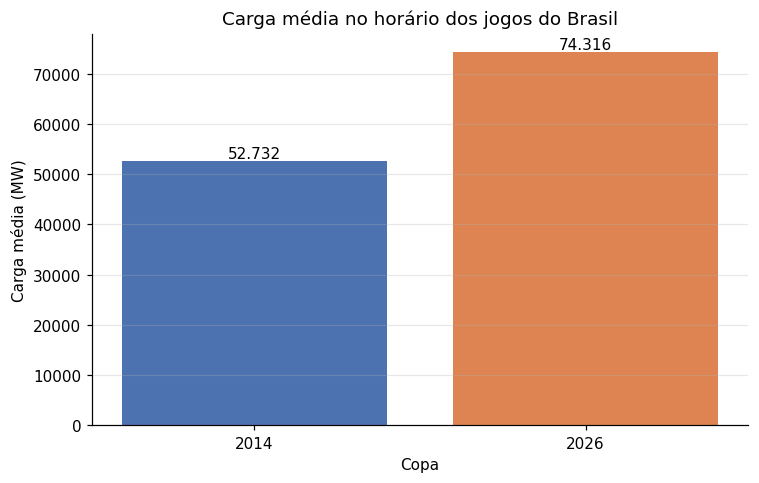

In [8]:
carga_media = pd.DataFrame({
    "Copa": ["2014", "2026"],
    "Carga média (MW)": [jogos_sin_2014["val_carga"].mean(), jogos_sin_2026["val_carga"].mean()],
})

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(carga_media["Copa"], carga_media["Carga média (MW)"], color=["#4C72B0", "#DD8452"])

ax.set_title("Carga média no horário dos jogos do Brasil")
ax.set_xlabel("Copa")
ax.set_ylabel("Carga média (MW)")
ax.grid(axis="y", alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2, altura, f"{altura:,.0f}".replace(",", "."),
            ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 8. Gráfico 2 — Composição da geração

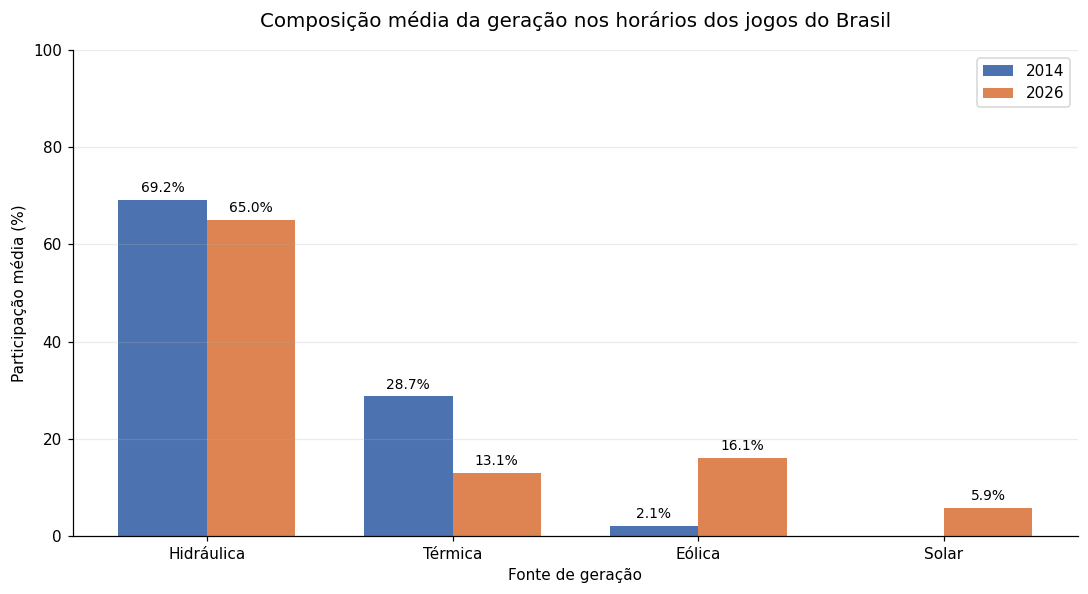

In [9]:
fontes_grafico = list(FONTES.keys())
dados_grafico = participacao_pct.set_index("Ano")[fontes_grafico]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(fontes_grafico))
largura = 0.36

barras_2014 = ax.bar(x - largura / 2, dados_grafico.loc[2014], largura, label="2014", color="#4C72B0")
barras_2026 = ax.bar(x + largura / 2, dados_grafico.loc[2026], largura, label="2026", color="#DD8452")

ax.set_title("Composição média da geração nos horários dos jogos do Brasil", fontsize=13, pad=15)
ax.set_xlabel("Fonte de geração")
ax.set_ylabel("Participação média (%)")
ax.set_xticks(x)
ax.set_xticklabels(fontes_grafico)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for barras in (barras_2014, barras_2026):
    for barra in barras:
        altura = barra.get_height()
        if not np.isnan(altura):
            ax.text(barra.get_x() + barra.get_width() / 2, altura + 1, f"{altura:.1f}%",
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Gráfico 3 — Carga nos jogos × referência

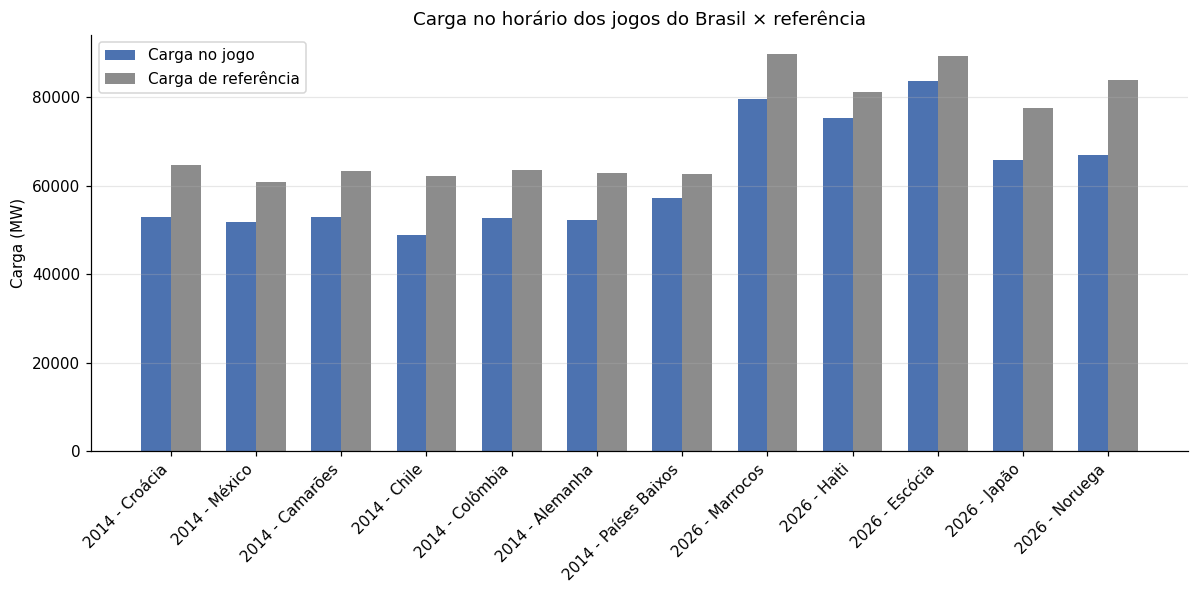

In [10]:
grafico_carga = pd.concat([
    carga_jogos_2014.assign(Copa="2014"),
    carga_jogos_2026.assign(Copa="2026"),
], ignore_index=True)

grafico_carga["Jogo"] = grafico_carga["Copa"] + " - " + grafico_carga["adversario"]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(grafico_carga))
largura = 0.35

ax.bar(x - largura / 2, grafico_carga["carga_jogo"], largura, label="Carga no jogo", color="#4C72B0")
ax.bar(x + largura / 2, grafico_carga["carga_referencia"], largura, label="Carga de referência", color="#8C8C8C")

ax.set_title("Carga no horário dos jogos do Brasil × referência")
ax.set_ylabel("Carga (MW)")
ax.set_xticks(x)
ax.set_xticklabels(grafico_carga["Jogo"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Gráfico 4 — Variação da carga por jogo

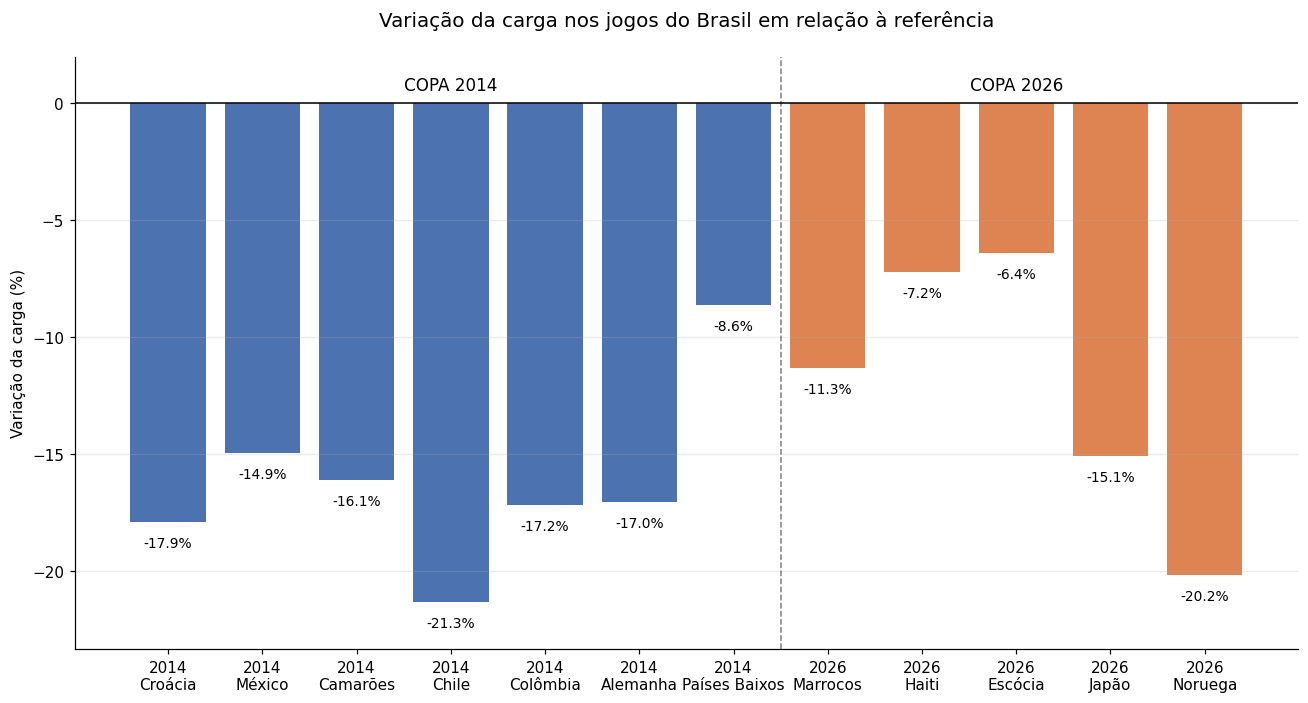

In [11]:
fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(grafico_carga))
cores = ["#4C72B0" if c == "2014" else "#DD8452" for c in grafico_carga["Copa"]]
barras = ax.bar(x, grafico_carga["variacao_%"], color=cores)

ax.axhline(0, linewidth=1, color="black")
n_2014 = len(carga_jogos_2014)
ax.axvline(n_2014 - 0.5, linestyle="--", linewidth=1, alpha=0.5, color="black")

ax.set_title("Variação da carga nos jogos do Brasil em relação à referência", fontsize=13, pad=20)
ax.set_ylabel("Variação da carga (%)")
ax.set_xticks(x)
ax.set_xticklabels([f"{ano}\n{adv}" for ano, adv in zip(grafico_carga["Copa"], grafico_carga["adversario"])])
ax.set_ylim(grafico_carga["variacao_%"].min() - 2, 2)
ax.grid(axis="y", alpha=0.25)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2, altura - 0.6, f"{altura:.1f}%",
            ha="center", va="top", fontsize=9)

ax.text(n_2014 / 2 - 0.5, 0.8, "COPA 2014", ha="center", va="center", fontsize=11)
ax.text(n_2014 + len(carga_jogos_2026) / 2 - 0.5, 0.8, "COPA 2026", ha="center", va="center", fontsize=11)

plt.tight_layout()
plt.show()

## 11. Conclusões executivas

*(texto gerado a partir dos dados calculados acima — não digitado à mão, para evitar que os números do texto fiquem desatualizados em relação aos gráficos)*

In [12]:
carga_2014 = jogos_sin_2014["val_carga"].mean()
carga_2026 = jogos_sin_2026["val_carga"].mean()
cresc_carga = (carga_2026 - carga_2014) / carga_2014 * 100

hidro_2014 = participacao_pct.set_index("Ano").loc[2014, "Hidráulica"]
hidro_2026 = participacao_pct.set_index("Ano").loc[2026, "Hidráulica"]
termica_2014 = participacao_pct.set_index("Ano").loc[2014, "Térmica"]
termica_2026 = participacao_pct.set_index("Ano").loc[2026, "Térmica"]
eolica_2014 = participacao_pct.set_index("Ano").loc[2014, "Eólica"]
eolica_2026 = participacao_pct.set_index("Ano").loc[2026, "Eólica"]
solar_2026 = participacao_pct.set_index("Ano").loc[2026, "Solar"]

var_2014 = carga_jogos_2014["variacao_%"].mean()
var_2026 = carga_jogos_2026["variacao_%"].mean()

texto = f'''
### Objetivo

Analisar o comportamento da carga e da composição da geração do Sistema Interligado Nacional (SIN) nos horários dos jogos do Brasil nas Copas do Mundo de 2014 e 2026, comparando os resultados com uma referência de carga para os mesmos horários.

### Principais achados

**1. Crescimento da carga.** A carga média observada nos horários dos jogos passou de **{carga_2014:,.0f} MW em 2014** para **{carga_2026:,.0f} MW em 2026**, crescimento de aproximadamente **{cresc_carga:.1f}%**.

**2. Mudança na composição da geração.** A hidráulica seguiu predominante, mas sua participação caiu de **{hidro_2014:.1f}% para {hidro_2026:.1f}%**. A térmica recuou de **{termica_2014:.1f}% para {termica_2026:.1f}%**, enquanto a eólica saltou de **{eolica_2014:.1f}% para {eolica_2026:.1f}%** e a solar, sem dado disponível em 2014, chegou a **{solar_2026:.1f}%** em 2026.

**3. Carga durante os jogos vs. referência.** A variação média em relação à referência foi de **{var_2014:.1f}%** em 2014 e **{var_2026:.1f}%** em 2026 (teste de Wilcoxon: p={stat_2014.pvalue:.3f} e p={stat_2026.pvalue:.3f}, respectivamente — com poucos jogos, esses testes têm pouco poder estatístico e devem ser lidos com cautela).

### Limitações metodológicas

- Resultado observacional: não permite afirmar que os jogos *causaram* as variações de carga.
- A referência (±7 dias, mesmo horário) não controla totalmente por dia da semana, clima, temperatura ou feriados.
- O número de jogos difere entre os períodos (**{len(jogos_brasil_2014)} em 2014** vs. **{len(jogos_brasil_2026)} em 2026**), o que limita a comparabilidade direta e o poder dos testes estatísticos.
- Os horários dos jogos de 2026 foram apurados por pesquisa em veículos de imprensa esportiva; recomenda-se conferi-los contra a tabela oficial da FIFA antes de publicar o resultado.
'''

display(Markdown(texto))


### Objetivo

Analisar o comportamento da carga e da composição da geração do Sistema Interligado Nacional (SIN) nos horários dos jogos do Brasil nas Copas do Mundo de 2014 e 2026, comparando os resultados com uma referência de carga para os mesmos horários.

### Principais achados

**1. Crescimento da carga.** A carga média observada nos horários dos jogos passou de **52,732 MW em 2014** para **74,316 MW em 2026**, crescimento de aproximadamente **40.9%**.

**2. Mudança na composição da geração.** A hidráulica seguiu predominante, mas sua participação caiu de **69.2% para 65.0%**. A térmica recuou de **28.7% para 13.1%**, enquanto a eólica saltou de **2.1% para 16.1%** e a solar, sem dado disponível em 2014, chegou a **5.9%** em 2026.

**3. Carga durante os jogos vs. referência.** A variação média em relação à referência foi de **-16.2%** em 2014 e **-12.0%** em 2026 (teste de Wilcoxon: p=0.016 e p=0.062, respectivamente — com poucos jogos, esses testes têm pouco poder estatístico e devem ser lidos com cautela).

### Limitações metodológicas

- Resultado observacional: não permite afirmar que os jogos *causaram* as variações de carga.
- A referência (±7 dias, mesmo horário) não controla totalmente por dia da semana, clima, temperatura ou feriados.
- O número de jogos difere entre os períodos (**7 em 2014** vs. **5 em 2026**), o que limita a comparabilidade direta e o poder dos testes estatísticos.
- Os horários dos jogos de 2026 foram apurados por pesquisa em veículos de imprensa esportiva; recomenda-se conferi-los contra a tabela oficial da FIFA antes de publicar o resultado.
